# Metrics and Evaluacion - California Housing Dataset

In [164]:
from sklearn.datasets import fetch_california_housing

x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [165]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


<Axes: xlabel='MedHouseVal', ylabel='Count'>

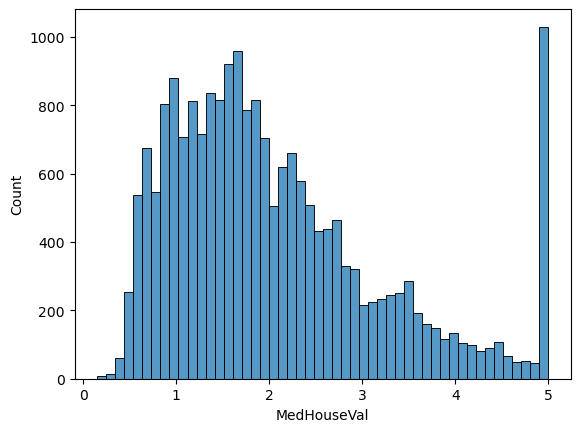

In [166]:
import seaborn as sns

sns.histplot(y, bins=50)

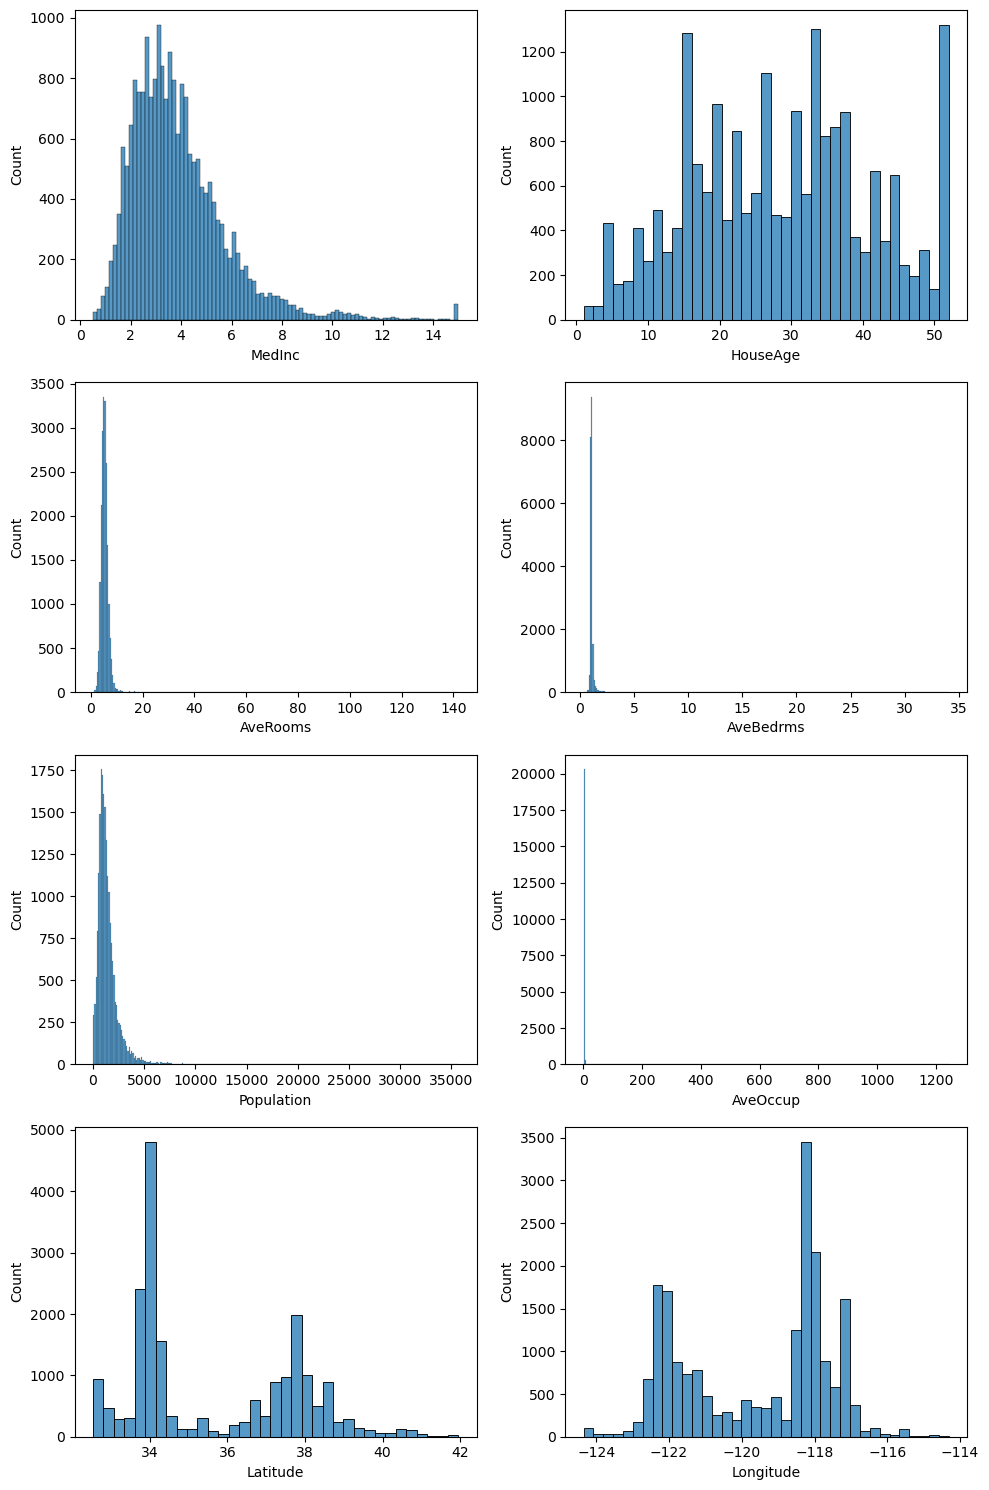

In [167]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), x.columns):
    sns.histplot(x[col], ax=ax)

plt.tight_layout()

<Axes: xlabel='Longitude', ylabel='Latitude'>

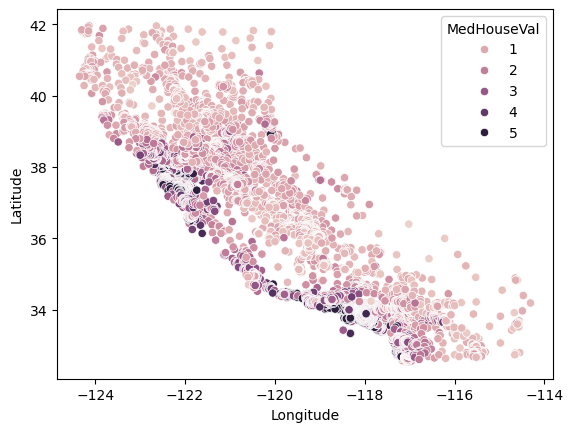

In [168]:
sns.scatterplot(x=x["Longitude"], y=x["Latitude"], hue=y)

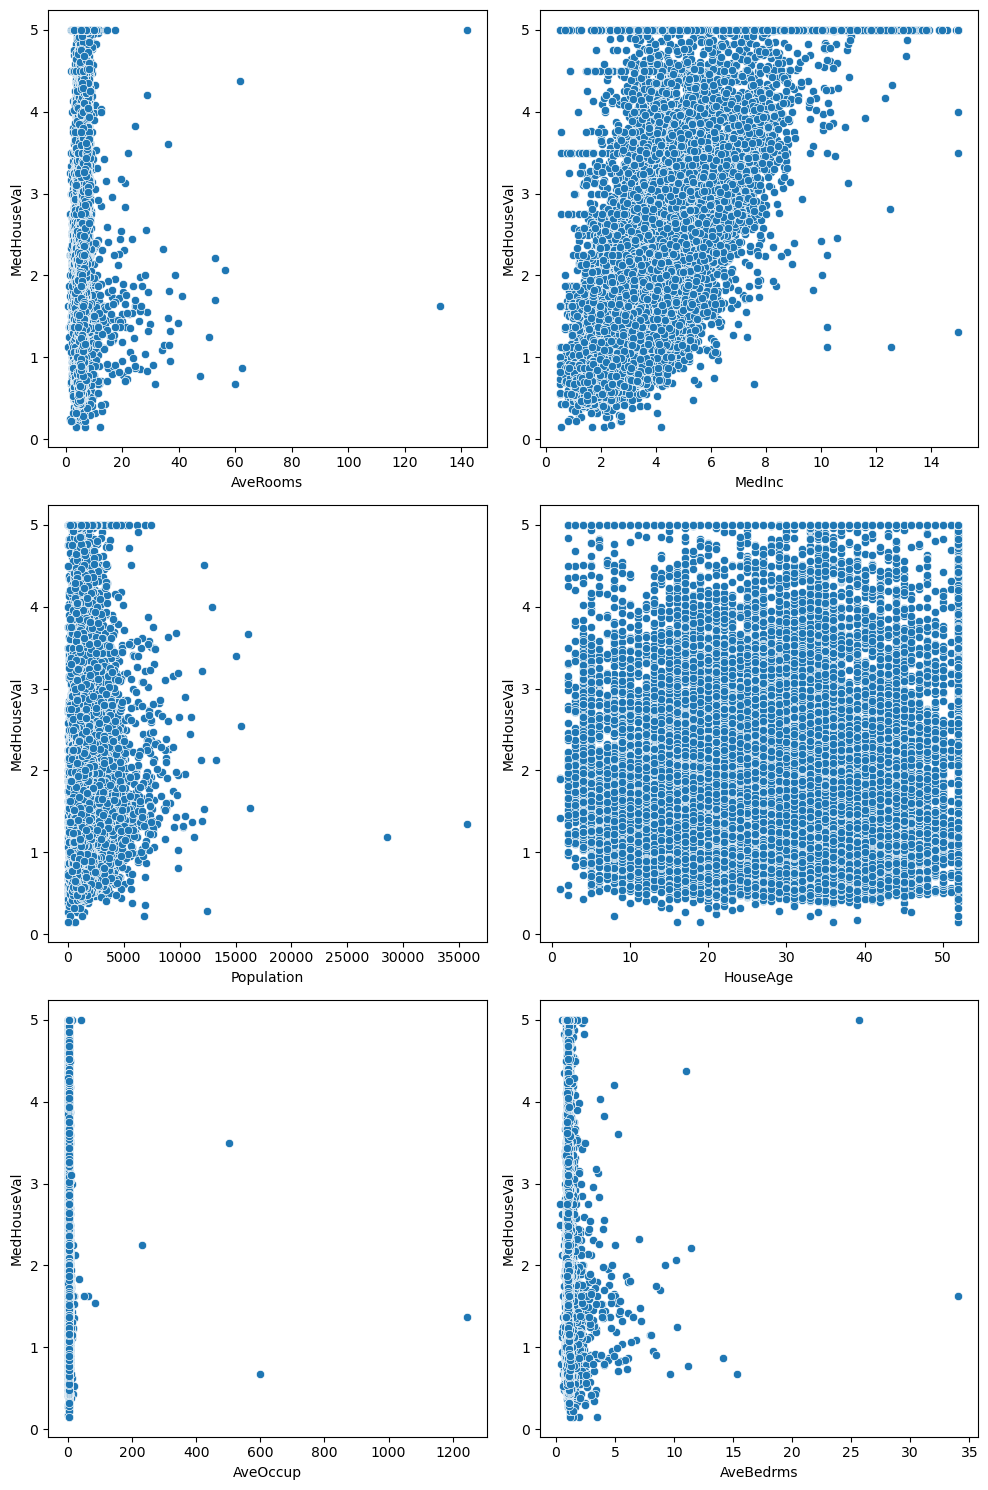

In [169]:
cols = set(x.columns) - {"Longitude","Latitude"}

fig, axs = plt.subplots(3, 2, figsize=(10,15))

for ax, col in zip(axs.ravel(), cols):
    sns.scatterplot(x=x[col],y=y, ax=ax)

plt.tight_layout()

<Axes: ylabel='MedInc'>

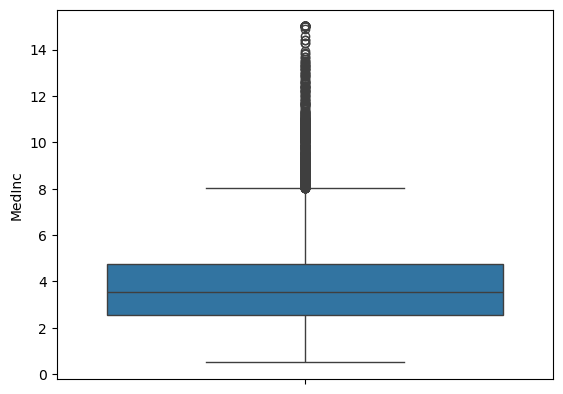

In [170]:
sns.boxplot(x["MedInc"])

In [171]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [172]:
from sklearn.model_selection import train_test_split

# 80% train, 20% temp
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=42
)

# 10% val, 10% test
x_val, x_test, y_val, y_test = train_test_split(
    x_temp, y_temp, test_size=0.5, random_state=42
)

In [173]:
from torch.utils.data import TensorDataset, Dataset, DataLoader
# Convertir a numpy y luego a tensores
x_train_tensor = torch.tensor(x_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)

x_val_tensor = torch.tensor(x_val.values, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32)

x_test_tensor = torch.tensor(x_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

# Crear los objetos Dataset
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
val_dataset = TensorDataset(x_val_tensor, y_val_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

amount_dataset = len(train_dataset) + len(val_dataset) + len(test_dataset)

print(f"Dataset de entrenamiento listo con {len(train_dataset)} muestras ({len(train_dataset)/amount_dataset * 100:.0f}%).")
print(f"Dataset de validación listo con {len(val_dataset)} muestras ({len(val_dataset)/amount_dataset * 100:.0f}%).")
print(f"Dataset de prueba listo con {len(test_dataset)} muestras ({len(test_dataset)/amount_dataset * 100:.0f}%).")

Dataset de entrenamiento listo con 16512 muestras (80%).
Dataset de validación listo con 2064 muestras (10%).
Dataset de prueba listo con 2064 muestras (10%).


## Preprocesamiento

In [174]:
import torch.nn as nn

class ScalingLayer(nn.Module):
    def __init__(self, mean: torch.Tensor, std: torch.Tensor, lower: torch.Tensor, upper: torch.Tensor):
        super().__init__()
        # Se registran los 4 parámetros estadísticos como buffers
        self.register_buffer('mean', mean) 
        self.register_buffer('std', std) 
        self.register_buffer('lower_limit', lower)
        self.register_buffer('upper_limit', upper)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Separar variables (suponiendo que las primeras 6 son numéricas y las 2 últimas geográficas)
        x_numeric = X[:, :6]
        x_geo = X[:, 6:] 

        # 1. Manejo de Outliers mediante Clipping
        x_clipped = torch.clamp(x_numeric, self.lower_limit, self.upper_limit)
        
        # 2. Standard Scaling
        x_scaled = (x_clipped - self.mean) / (self.std + 1e-8) 
        
        # 3. Concatenación
        return torch.cat([x_scaled, x_geo], dim=1)

class CaliforniaHousingModel(nn.Module):
    def __init__(self, mean, std, lower_limit, upper_limit, hidden_sizes=[64], output_size=1):
        super().__init__()
        # El preprocesamiento ahora es la primera capa del modelo
        self.preprocessing = ScalingLayer(mean, std, lower_limit, upper_limit)
        
        # Construcción dinámica de la red según 'hidden_sizes'
        layers = []
        input_dim = 8  # 6 numéricas procesadas + 2 geográficas


        # Agregamos las capas ocultas y ReLU
        for h_size in hidden_sizes:
            layers.append(nn.Linear(input_dim, h_size))
            layers.append(nn.ReLU())
            input_dim = h_size
            
        # Capa de salida (sin activación extra, CrossEntropyLoss hace el Softmax)
        layers.append(nn.Linear(input_dim, output_size))
        
        # nn.Sequential agrupa las capas para ejecutarlas en orden
        self.predictor = nn.Sequential(*layers)


    def forward(self, X: torch.Tensor) -> torch.Tensor:
        # Los datos crudos entran, se escalan y luego pasan a la red [cite: 142]
        X = self.preprocessing(X)
        return self.predictor(X)

## Model Training and Evaluation

In [175]:
# Configuraciones para los 3 experimentos
experimentos = [
    {
        "nombre": "Modelo 1 (Base - 1 capa)",
        "hidden_sizes": [128],
        "batch_size": 64,
        "lr": 0.001,
        "epochs": 5,
        "optimizer": "Adam"
    },
    {
        "nombre": "Modelo 2 (Profundo - SGD)",
        "hidden_sizes": [256, 128],
        "batch_size": 256,
        "lr": 0.01,
        "epochs": 10,
        "optimizer": "SGD"
    },
    {
        "nombre": "Modelo 3 (Estructura Piramidal - Adam)",
        "hidden_sizes": [128, 64],
        "batch_size": 32,
        "lr": 0.0005,
        "epochs": 5,
        "optimizer": "Adam"
    }
]

# Función de pérdida para regresión
criterion = nn.MSELoss()

In [176]:
def mean_absolute_error(y_pred, y_true):
    return torch.mean(torch.abs(y_true - y_pred))

def mean_squared_error(y_pred, y_true):
    return torch.mean(torch.pow(y_true - y_pred, 2))

def root_mean_squared_error(y_pred, y_true):
    mse = mean_squared_error(y_pred, y_true)
    return torch.sqrt(mse)

def r2_score(y_pred, y_true):
    mean_y = torch.mean(y_true)
    
    ss_total = torch.sum(torch.pow(y_true - mean_y, 2))
    ss_res = torch.sum(torch.pow(y_true - y_pred, 2))
    
    # Prevenir división por cero en caso de un batch extraño
    if ss_total == 0:
        return torch.tensor(0.0, device=y_true.device)
        
    return 1 - (ss_res / ss_total)

In [177]:
def evaluate(model, dataloader, criterion, device):
    """Calcula el Loss y el error absoluto medio de un dataloader completo."""
    model.eval()
    total_loss = 0.0
    
    
    # Listas para guardar las predicciones y etiquetas de todos los batches
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Paso 1: Forward pass 
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * inputs.size(0)
            
            # Paso 2: Obtener predicciones del batch
            preds = torch.argmax(outputs, dim=1)
            
            # Paso 3: Guardar en las listas
            all_preds.append(preds)
            all_labels.append(labels)
            

    
    # Concatenamos las listas para tener un solo tensor gigante con todo el dataset
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    avg_loss = total_loss / len(dataloader.dataset)
    
    mae = mean_absolute_error(all_preds, all_labels)
    mse = mean_squared_error(all_preds, all_labels)
    rmse = root_mean_squared_error(all_preds, all_labels)
    r2 = r2_score(all_preds, all_labels)


    return avg_loss, mae, mse, rmse, r2



def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    historial = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        
        # Entrenamiento
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            
            # Obligamos a labels a tener la misma forma que outputs
            labels = labels.view_as(outputs)
            
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            
        train_loss = train_loss / len(train_loader.dataset)
        
        # Validación
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                
                outputs = model(inputs)
                labels = labels.view_as(outputs)
                
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
                # Calculamos el Error Absoluto Medio (MAE) como métrica interpretable
                mae = mean_absolute_error(labels, outputs)
                val_mae += mae.item() * inputs.size(0)
                
        val_loss = val_loss / len(val_loader.dataset)
        val_mae = val_mae / len(val_loader.dataset)
        
        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['val_mae'].append(val_mae)
        
        # Imprimimos resultados coherentes para regresión
        print(f"Época {epoch+1}/{epochs} | Train Loss (MSE): {train_loss:.4f} | Val Loss (MSE): {val_loss:.4f} | Val MAE: {val_mae:.4f}")
        
    return historial

In [178]:
import torch.optim as optim
resultados_experimentos = []
mejores_pesos = None
mejor_val_mae = 0.0
mejor_modelo_idx = -1

for idx, config in enumerate(experimentos):
    print(f"Iniciando {config['nombre']}")
    print(f"Arquitectura: Ocultas {config['hidden_sizes']}, Batch: {config['batch_size']}, LR: {config['lr']}, Opt: {config['optimizer']}\n")
    
    # 1. Crear DataLoaders con el Batch Size del experimento
    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)
    
    cols_to_process = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup']
    x_train_subset = x_train[cols_to_process]

    mean_train = torch.tensor(x_train_subset.values, dtype=torch.float32).mean(dim=0).to(device)
    std_train = torch.tensor(x_train_subset.values, dtype=torch.float32).std(dim=0).to(device)

    # Definimos umbrales para outliers (ej. 3 desviaciones estándar)
    lower_limit = mean_train - 3 * std_train
    upper_limit = mean_train + 3 * std_train

    # 2. Instanciar Modelo
    model = CaliforniaHousingModel(mean_train, std_train, lower_limit, upper_limit).to(device)    
    # 3. Definir Optimizador
    if config['optimizer'] == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=config['lr'])
    else:
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9)
        
    # 4. Entrenar
    historial = train_model(model, train_loader, val_loader, criterion, optimizer, config['epochs'], device)
    
    # Evaluar si es el mejor modelo (basado en la última época de validación)
    val_acc_final = historial['val_mae'][-1]
    if val_acc_final > mejor_val_mae:
        mejor_val_mae = val_acc_final
        mejor_modelo_idx = idx
        # Guardamos el mejor modelo y sus pesos
        mejor_modelo = model
    
    resultados_experimentos.append(historial)
    print("\n")

Iniciando Modelo 1 (Base - 1 capa)
Arquitectura: Ocultas [128], Batch: 64, LR: 0.001, Opt: Adam

Época 1/5 | Train Loss (MSE): 0.9396 | Val Loss (MSE): 0.6911 | Val MAE: 0.6542
Época 2/5 | Train Loss (MSE): 0.6418 | Val Loss (MSE): 0.6409 | Val MAE: 0.5652
Época 3/5 | Train Loss (MSE): 0.5901 | Val Loss (MSE): 0.5689 | Val MAE: 0.5639
Época 4/5 | Train Loss (MSE): 0.5515 | Val Loss (MSE): 0.5483 | Val MAE: 0.5360
Época 5/5 | Train Loss (MSE): 0.5426 | Val Loss (MSE): 0.6638 | Val MAE: 0.5576


Iniciando Modelo 2 (Profundo - SGD)
Arquitectura: Ocultas [256, 128], Batch: 256, LR: 0.01, Opt: SGD

Época 1/10 | Train Loss (MSE): 2430417.0163 | Val Loss (MSE): 1931.8654 | Val MAE: 43.9380
Época 2/10 | Train Loss (MSE): 214.4921 | Val Loss (MSE): 5.8238 | Val MAE: 2.2221
Época 3/10 | Train Loss (MSE): 1.6975 | Val Loss (MSE): 1.3183 | Val MAE: 0.8903
Época 4/10 | Train Loss (MSE): 1.3378 | Val Loss (MSE): 1.3170 | Val MAE: 0.9009
Época 5/10 | Train Loss (MSE): 1.3373 | Val Loss (MSE): 1.3180 

In [179]:
print(f"El mejor modelo fue el Experimento {mejor_modelo_idx + 1}: {experimentos[mejor_modelo_idx]['nombre']}")
print(f"MAE Máxima: {mejor_val_mae*100:.2f}%")

El mejor modelo fue el Experimento 2: Modelo 2 (Profundo - SGD)
MAE Máxima: 90.13%


In [180]:
def evaluacion_final(_modelo_idx, _model, _criterion, _device):
    # DataLoader para Test (el batch_size no afecta los resultados, solo la velocidad)
    test_loader = DataLoader(test_dataset, batch_size=experimentos[_modelo_idx]['batch_size'], shuffle=False)

    # Evaluamos el modelo campeón
    test_loss, test_mae, test_mse, test_rmse, test_r2 = evaluate(_model, test_loader, _criterion, _device)

    print(f"\n[RESULTADOS FINALES EN TEST CON EL {experimentos[_modelo_idx]['nombre'].upper()}]")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test MAE: {test_mae:.4f}")
    print(f"Test MSE: {test_mse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Test R2 Score: {test_r2:.4f}")

evaluacion_final(mejor_modelo_idx, mejor_modelo, criterion, device)



[RESULTADOS FINALES EN TEST CON EL MODELO 2 (PROFUNDO - SGD)]
Test Loss: 1.3038
Test MAE: 2.0735
Test MSE: 5.6028
Test RMSE: 2.3670
Test R2 Score: -3.2987


/home/jvazquez/miniconda3/envs/jupyter-env/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([256])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/home/jvazquez/miniconda3/envs/jupyter-env/lib/python3.11/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([16])) that is different to the input size (torch.Size([16, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
